# Data Quality Assessment (QA/QC)
This notebook helps evaluates the spatial datasets used in this study. The QA workflow verifies:
- coordinate reference systems (CRS)
- raster resolution
- spatial extent
- geometry validity
- nodata values
- value ranges

In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rxr
import yaml

warnings.filterwarnings("ignore")

## Load Config and Paths

In [2]:
# =========================================================
# LOAD CONFIG
# =========================================================

CONFIG_PATH = "../config/config.yaml"

with open(CONFIG_PATH, "r") as file:
    config = yaml.safe_load(file)

REGION_NAME = config["study_area"]["region_name"]


# =========================================================
# RAW DATA DIRECTORY
# =========================================================

RAW_DATA_DIR = Path(
    "../data/raw"
)

print("Raw data directory:")
print(RAW_DATA_DIR)

print("\nDirectory exists:")
print(RAW_DATA_DIR.exists())


# =========================================================
# FILE PATHS
# =========================================================

# BOUNDARY

BOUNDARY_PATH = (
    RAW_DATA_DIR /
    "boundaries" /
    "boundary.geojson"
)

# DEM

DEM_PATH = (
    RAW_DATA_DIR /
    "dem" /
    "dem.tif"
)

# LAND COVER

LULC_PATH = (
    RAW_DATA_DIR /
    "landcover" /
    "landcover.tif"
)

# PRECIPITATION

PRECIP_PATH = (
    RAW_DATA_DIR /
    "climate" /
    "precipitation.tif"
)

# POPULATION

POPULATION_PATH = (
    RAW_DATA_DIR /
    "population" /
    "population.geojson"
)

# ROADS

ROADS_PATH = (
    RAW_DATA_DIR /
    "roads" /
    "roads.geojson"
)

# WILDFIRE

WILDFIRE_PATH = (
    RAW_DATA_DIR /
    "wildfire" /
    "wildfire_history.geojson"
)

# VERIFY FILES

print("\nBoundary:")
print(BOUNDARY_PATH)

print("\nDEM:")
print(DEM_PATH)

print("\nLand Cover:")
print(LULC_PATH)

print("\nPrecipitation:")
print(PRECIP_PATH)

print("\nPopulation:")
print(POPULATION_PATH)

print("\nRoads:")
print(ROADS_PATH)

print("\nWildfire:")
print(WILDFIRE_PATH)

Raw data directory:
../data/raw

Directory exists:
True

Boundary:
../data/raw/boundaries/boundary.geojson

DEM:
../data/raw/dem/dem.tif

Land Cover:
../data/raw/landcover/landcover.tif

Precipitation:
../data/raw/climate/precipitation.tif

Population:
../data/raw/population/population.geojson

Roads:
../data/raw/roads/roads.geojson

Wildfire:
../data/raw/wildfire/wildfire_history.geojson


## Helper Functions

In [3]:
# =========================================================
# RASTER QA FUNCTION
# =========================================================

def raster_qa(
    raster_path,
    layer_name,
    plot=True
):
    """
    QA workflow for raster datasets.
    """

    raster = rxr.open_rasterio(
        raster_path,
        masked=True
    ).squeeze()

    print("\n===================================")
    print(layer_name.upper())
    print("===================================")

    print(f"\nCRS: {raster.rio.crs}")

    print(
        f"Resolution: "
        f"{raster.rio.resolution()}"
    )

    print(
        f"Shape: "
        f"{raster.shape}"
    )

    print(
        f"Nodata: "
        f"{raster.rio.nodata}"
    )

    print(
        f"Bounds: "
        f"{raster.rio.bounds()}"
    )

    print(
        f"Min value: "
        f"{float(raster.min().values):.2f}"
    )

    print(
        f"Max value: "
        f"{float(raster.max().values):.2f}"
    )

    # -----------------------------------------------------
    # LAND COVER CLASSES
    # -----------------------------------------------------

    if layer_name == "Land Cover":

        unique_classes = np.unique(
            raster.values[
                ~np.isnan(raster.values)
            ]
        )

        print(
            f"\nUnique classes:\n"
            f"{unique_classes}"
        )

    # -----------------------------------------------------
    # OPTIONAL PLOT
    # -----------------------------------------------------

    if plot:

        fig, ax = plt.subplots(
            figsize=(8, 6)
        )

        raster.plot(ax=ax)

        ax.set_title(layer_name)

        plt.show()

    return raster

# =========================================================
# VECTOR QA FUNCTION
# =========================================================

def vector_qa(
    vector_path,
    layer_name
):
    """
    QA workflow for vector datasets.
    """

    # -----------------------------------------------------
    # LOAD VECTOR
    # -----------------------------------------------------

    gdf = gpd.read_file(
        vector_path
    )

    # -----------------------------------------------------
    # HEADER
    # -----------------------------------------------------

    print("\n===================================")
    print(layer_name.upper())
    print("===================================")

    # -----------------------------------------------------
    # BASIC QA
    # -----------------------------------------------------

    print(f"\nCRS: {gdf.crs}")

    print(
        f"Feature count: "
        f"{len(gdf)}"
    )

    print(
        "\nGeometry validity:"
    )

    print(
        gdf.is_valid.value_counts()
    )

    print(
        f"\nBounds: "
        f"{gdf.total_bounds}"
    )

    # -----------------------------------------------------
    # POPULATION QA
    # -----------------------------------------------------

    if layer_name == "Population":

        print(
            "\nPopulation density summary:"
        )

        print(
            gdf[
                "population_density"
            ].describe()
        )

    # -----------------------------------------------------
    # WILDFIRE YEAR RANGE
    # -----------------------------------------------------

    year_columns = [

        col for col in gdf.columns

        if "year" in col.lower()

    ]

    if (
        layer_name == "Wildfire"
        and len(year_columns) > 0
    ):

        year_col = year_columns[0]

        print(
            f"\nWildfire year range: "
            f"{gdf[year_col].min()} "
            f"to "
            f"{gdf[year_col].max()}"
        )

    # -----------------------------------------------------
    # PLOT
    # -----------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    gdf.plot(
        ax=ax,
        linewidth=0.5
    )

    ax.set_title(layer_name)

    plt.show()

    return gdf

## boundary QA


BOUNDARY

CRS: EPSG:3310
Feature count: 1

Geometry validity:
True    1
Name: count, dtype: int64

Bounds: [-177005.82775542  143392.57904555  -92405.84778004  238259.69514585]


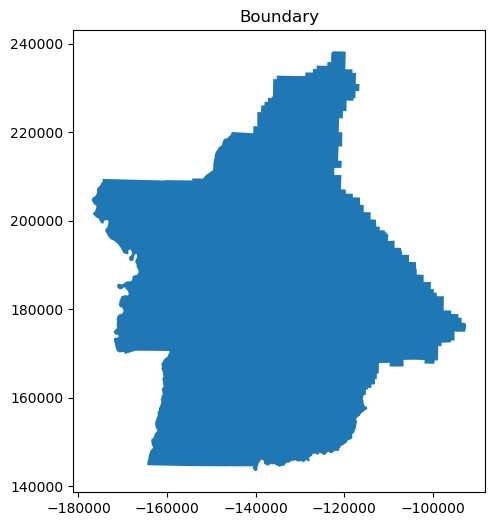

In [4]:
boundary = vector_qa(
    BOUNDARY_PATH,
    "Boundary"
)

## DEM QA


DEM

CRS: EPSG:4326
Resolution: (0.0002777777777777779, -0.00027777777777777843)
Shape: (5939, 7892)
Nodata: None
Bounds: (-122.06958333333333, 38.50236111111111, -119.87736111111111, 40.15208333333334)
Min value: -6.97
Max value: 3310.92


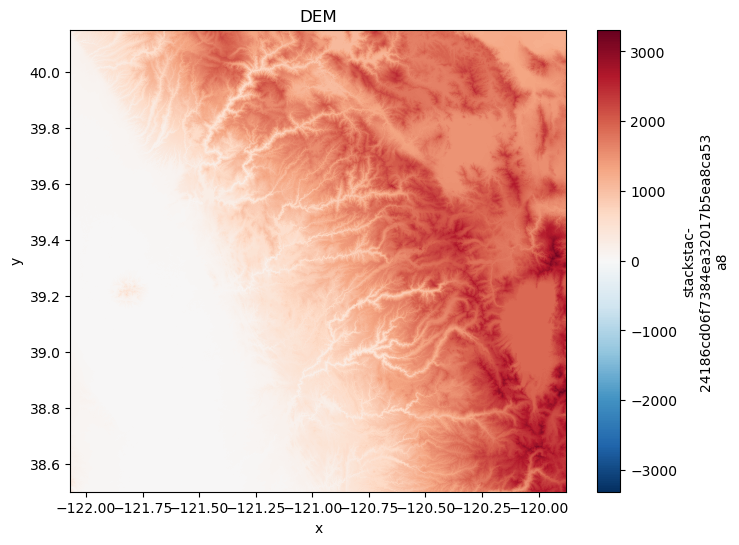

In [5]:
dem = raster_qa(
    DEM_PATH,
    "DEM"
)

In [ ]:
## Landcover QA

In [6]:
lulc = raster_qa(
    LULC_PATH,
    "Land Cover",
    plot=False
)


LAND COVER

CRS: EPSG:4326
Resolution: (0.00011712474135444479, -9.046788287833888e-05)
Shape: (9466, 8477)
Nodata: None
Bounds: (-122.06957224731673, 39.29558437309379, -121.07670581485509, 40.15195335242015)
Min value: 1.00
Max value: 11.00

Unique classes:
[ 1.  2.  4.  5.  7.  8.  9. 11.]


## Precipitation QA

In [7]:
precip = raster_qa(
    PRECIP_PATH,
    "Precipitation",
    plot=False
)


PRECIPITATION

CRS: EPSG:4326
Resolution: (0.0625, 0.0625)
Shape: (195, 179)
Nodata: None
Bounds: (-124.5625, 31.5625, -113.375, 43.75)
Min value: 0.09
Max value: 10.64


## Roads QA


ROADS

CRS: EPSG:4326
Feature count: 31729

Geometry validity:
True    31729
Name: count, dtype: int64

Bounds: [-122.046881    39.303948  -121.0964328   40.1208575]


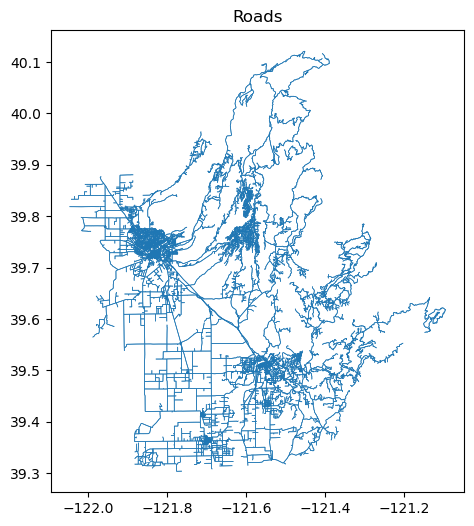

In [8]:
roads = vector_qa(
    ROADS_PATH,
    "Roads"
)

## Population QA


POPULATION

CRS: EPSG:3310
Feature count: 54

Geometry validity:
True    54
Name: count, dtype: int64

Bounds: [-177005.82775542  143392.57904555  -92405.84778004  238272.37981488]

Population density summary:
count      54.000000
mean      854.610636
std      1091.156391
min         1.909560
25%        48.668959
50%       391.539859
75%      1451.762440
max      4704.202544
Name: population_density, dtype: float64


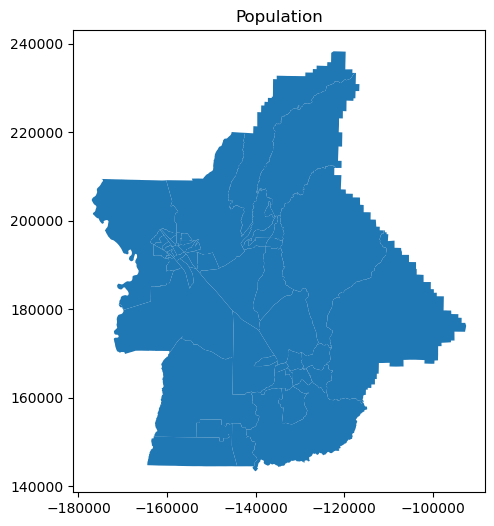

In [9]:
population = vector_qa(
    POPULATION_PATH,
    "Population"
)

## Wildfire QA


WILDFIRE

CRS: EPSG:3857
Feature count: 4580

Geometry validity:
True     4281
False     299
Name: count, dtype: int64

Bounds: [-13829861.5415   3835214.8816 -12705605.9618   5178118.2687]

Wildfire year range: 2015 to 2025


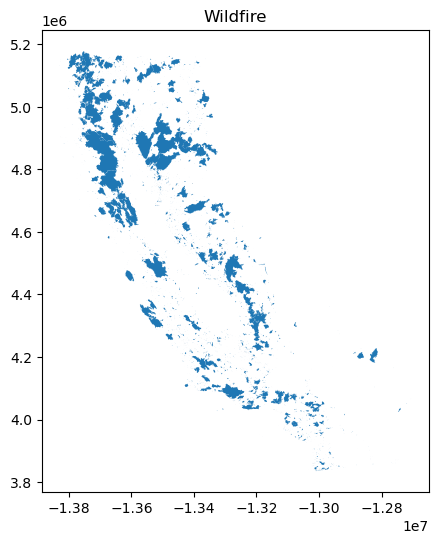

In [10]:
wildfire = vector_qa(
    WILDFIRE_PATH,
    "Wildfire"
)

## Boundary QA

  STATEFP COUNTYFP  COUNTYNS         GEOIDFQ  GEOID   NAME      NAMELSAD  \
0      06      007  01675842  0500000US06007  06007  Butte  Butte County   

  STUSPS  STATE_NAME LSAD       ALAND     AWATER  \
0     CA  California   06  4238488659  105260548   

                                            geometry  
0  POLYGON ((-176942.974 204861.008, -176783.151 ...  

Boundary CRS:
EPSG:3310

Number of Features:
1


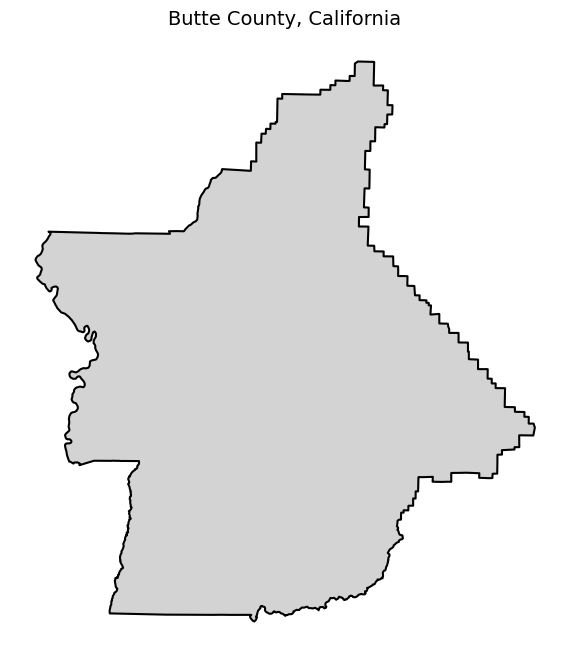

In [2]:
boundary = gpd.read_file(
    "../data/raw/boundaries/"
    "butte_county_boundary.geojson"
)

# ---------------------------------------------------------
# INSPECT DATA
# ---------------------------------------------------------

print(boundary.head())

print("\nBoundary CRS:")
print(boundary.crs)

print("\nNumber of Features:")
print(len(boundary))


# ---------------------------------------------------------
# PLOT BOUNDARY
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 8)
)

boundary.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray",
    linewidth=1.5
)

ax.set_title(
    "Butte County, California",
    fontsize=14
)

ax.set_axis_off()

plt.show()


## DEM QA


DEM Summary:
<xarray.DataArray (y: 3083, x: 3574)> Size: 88MB
[11018642 values with dtype=float64]
Coordinates:
  * y            (y) float64 25kB 40.15 40.15 40.15 40.15 ... 39.3 39.3 39.3
  * x            (x) float64 29kB -122.1 -122.1 -122.1 ... -121.1 -121.1 -121.1
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    resolution:     0.0002777777777777778
    spec:           RasterSpec(epsg=4326, bounds=(-122.06944444444444, 39.295...
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      stackstac-a0f5d9aed315284ea7923bf30d204942

DEM CRS:
EPSG:4326

DEM Shape:
(3083, 3574)


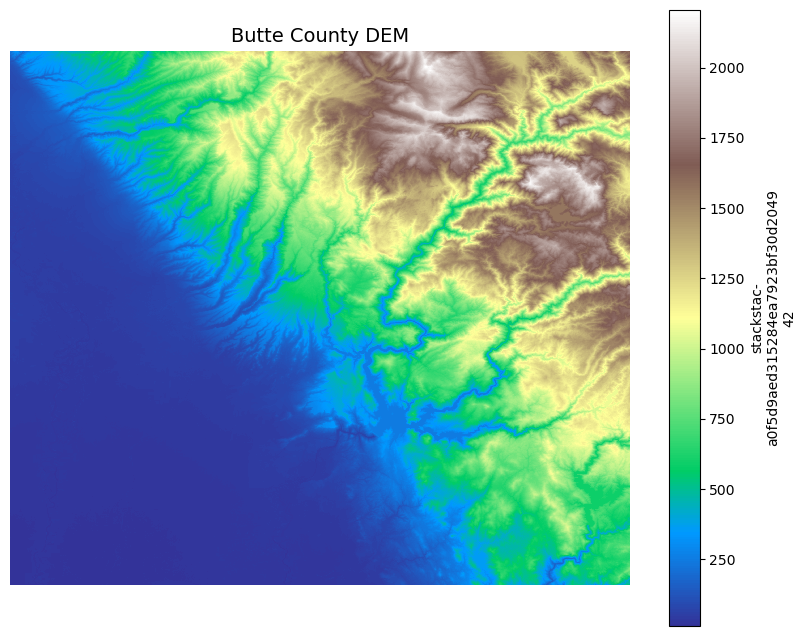

In [3]:
# LOAD DEM 
dem = rioxarray.open_rasterio(
    "../data/raw/dem/"
    "butte_county_dem.tif",
    masked=True
).squeeze()

# INSPECT DEM
print("\nDEM Summary:")
print(dem)

print("\nDEM CRS:")
print(dem.rio.crs)

print("\nDEM Shape:")
print(dem.shape)

# PLOT DEM
fig, ax = plt.subplots(
    figsize=(10, 8)
)

dem.plot(
    ax=ax,
    cmap="terrain"
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1
)

ax.set_title(
    "Butte County DEM",
    fontsize=14
)

ax.set_axis_off()

plt.show()

## QA Wildfire Perimeters


   OBJECTID  YEAR_ STATE AGENCY UNIT_ID  FIRE_NAME   INC_NUM  \
0         1   2025    CA    USF     LPF    GIFFORD  00002181   
1         2   2025    CA    USF     LPF      MADRE  00001817   
2         3   2025    CA    USF     SNF     GARNET  00001684   
3         4   2025    CA    CDF     FKU       SALT  00018739   
4         5   2025    CA    CDF     LDF  PALISADES  00000738   

                      ALARM_DATE                      CONT_DATE  CAUSE  ...  \
0  Fri, 01 Aug 2025 00:00:00 GMT  Tue, 14 Oct 2025 00:00:00 GMT     14  ...   
1  Wed, 02 Jul 2025 00:00:00 GMT  Sat, 26 Jul 2025 00:00:00 GMT     14  ...   
2  Sun, 24 Aug 2025 00:00:00 GMT  Thu, 23 Oct 2025 00:00:00 GMT      1  ...   
3  Tue, 02 Sep 2025 00:00:00 GMT  Wed, 17 Sep 2025 00:00:00 GMT      1  ...   
4  Tue, 07 Jan 2025 00:00:00 GMT  Fri, 31 Jan 2025 00:00:00 GMT     14  ...   

   OBJECTIVE  GIS_ACRES                            COMMENTS COMPLEX_NAME  \
0        1.0  131613.50                                None     

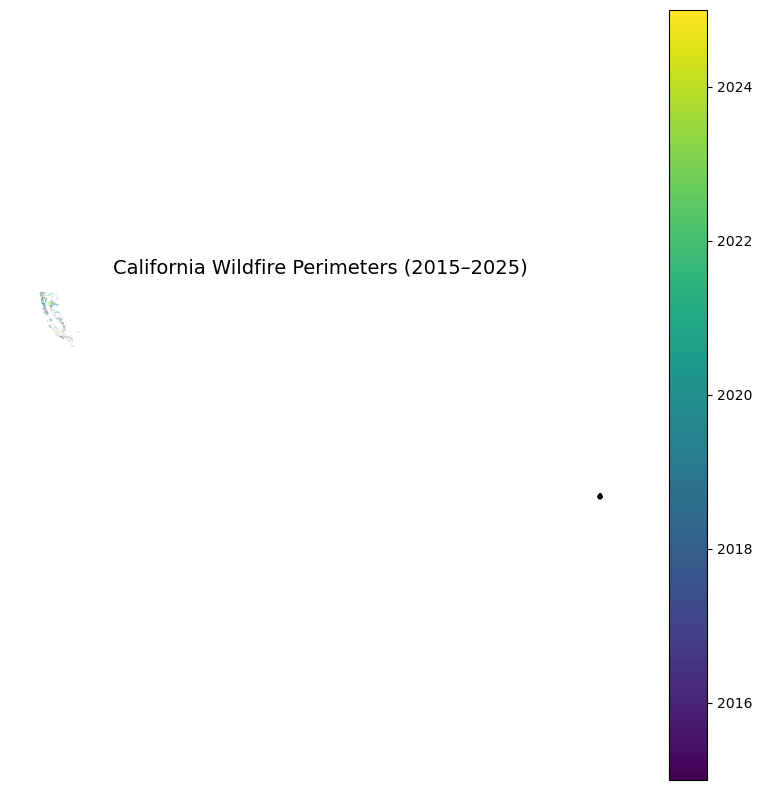

In [4]:
# ---------------------------------------------------------
# LOAD WILDFIRE DATA
# ---------------------------------------------------------

wildfire = gpd.read_file(
    "../data/raw/wildfire/"
    "butte_county_wildfire_history.geojson"
)

# ---------------------------------------------------------
# INSPECT DATA
# ---------------------------------------------------------

print(wildfire.head())

print("\nWildfire CRS:")
print(wildfire.crs)

print("\nNumber of Wildfire Records:")
print(len(wildfire))


# ---------------------------------------------------------
# PLOT WILDFIRE PERIMETERS
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

wildfire.plot(
    ax=ax,
    column="YEAR_FILTER",
    legend=True,
    alpha=0.6,
    linewidth=0.3
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.5
)

ax.set_title(
    "California Wildfire Perimeters (2015–2025)",
    fontsize=14
)

ax.set_axis_off()

plt.show()


Land Cover Summary:
<xarray.DataArray (y: 9466, x: 8477)> Size: 642MB
[80243282 values with dtype=float64]
Coordinates:
  * y            (y) float64 76kB 40.15 40.15 40.15 40.15 ... 39.3 39.3 39.3
  * x            (x) float64 68kB -122.1 -122.1 -122.1 ... -121.1 -121.1 -121.1
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    resolution_xy:  (0.00011712474135444413, 9.046788287833878e-05)
    spec:           RasterSpec(epsg=4326, bounds=(-122.06951368494605, 39.295...
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      stackstac-93e56daa417487ac3b70c9b56ff3c8bb

Land Cover CRS:
EPSG:4326

Land Cover Shape:
(9466, 8477)

Unique Land Cover Classes:
[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(11.0)]


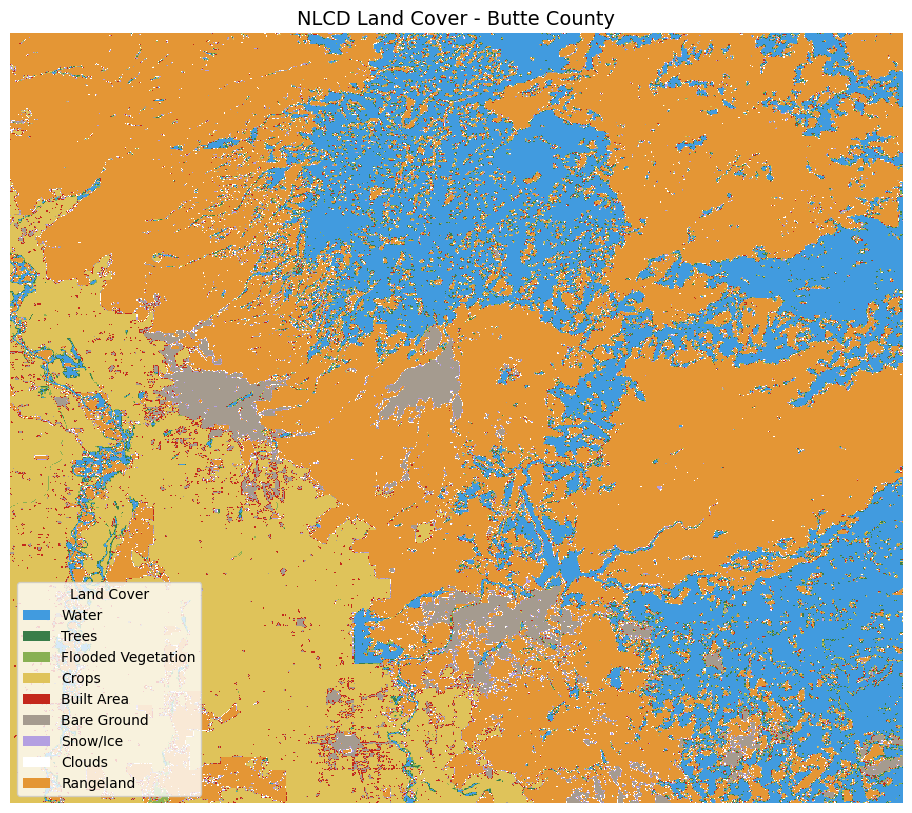

In [7]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# ---------------------------------------------------------
# LOAD LAND COVER RASTER
# ---------------------------------------------------------

landcover = rioxarray.open_rasterio(
    "../data/raw/landcover/"
    "butte_county_nlcd_landcover.tif",
    masked=True
).squeeze()


# ---------------------------------------------------------
# INSPECT RASTER
# ---------------------------------------------------------

print("\nLand Cover Summary:")
print(landcover)

print("\nLand Cover CRS:")
print(landcover.rio.crs)

print("\nLand Cover Shape:")
print(landcover.shape)

print("\nUnique Land Cover Classes:")
print(sorted(set(
    landcover.values.flatten()
)))


# ---------------------------------------------------------
# DOWNSAMPLE FOR VISUALIZATION
# ---------------------------------------------------------

landcover_preview = landcover.coarsen(
    x=10,
    y=10,
    boundary="trim"
).mean()


# ---------------------------------------------------------
# LAND COVER CLASS LABELS
# ---------------------------------------------------------

class_labels = {
    1: "Water",
    2: "Trees",
    4: "Flooded Vegetation",
    5: "Crops",
    7: "Built Area",
    8: "Bare Ground",
    9: "Snow/Ice",
    10: "Clouds",
    11: "Rangeland"
}


# ---------------------------------------------------------
# COLOR MAP
# ---------------------------------------------------------

colors = [
    "#419BDF",  # Water
    "#397D49",  # Trees
    "#88B053",  # Flooded vegetation
    "#DFC35A",  # Crops
    "#C4281B",  # Built area
    "#A59B8F",  # Bare ground
    "#B39FE1",  # Snow/Ice
    "#FFFFFF",  # Clouds
    "#E49635"   # Rangeland
]

cmap = ListedColormap(colors)


# ---------------------------------------------------------
# PLOT LAND COVER
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 10)
)

landcover_preview.plot(
    ax=ax,
    cmap=cmap,
    add_colorbar=False
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.5
)


# ---------------------------------------------------------
# CUSTOM LEGEND
# ---------------------------------------------------------

legend_elements = [
    Patch(
        facecolor=color,
        label=label
    )
    for color, label in zip(
        colors,
        class_labels.values()
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    title="Land Cover"
)


# ---------------------------------------------------------
# FINAL MAP SETTINGS
# ---------------------------------------------------------

ax.set_title(
    "NLCD Land Cover - Butte County",
    fontsize=14
)

ax.set_axis_off()

plt.show()